<a href="https://colab.research.google.com/github/sakethnandam/exoplanet-detection/blob/main/exoplanet_autoencoder_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup

In [1]:
!pip install -q lightkurve astroquery pandas numpy matplotlib scikit-learn torch torchvision tqdm

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.9/256.9 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 102.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 155.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 195.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.2/112.2 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as mpl_cm
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import lightkurve as lk
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    roc_auc_score, f1_score, precision_score, recall_score,
    balanced_accuracy_score
)
from sklearn.model_selection import train_test_split

np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cpu


## Hyperparameters

In [3]:
WINDOW_SIZE       = 256
SAMPLE_SIZE_FP    = 500
SAMPLE_SIZE_POS   = 500
BATCH_SIZE        = 64
LEARNING_RATE_AE  = 1e-3
LEARNING_RATE_CLF = 1e-4
AE_EPOCHS         = 80
CLF_EPOCHS        = 100
LATENT_DIM        = 64
THRESHOLD_SIGMA   = 2.0

# Focal Loss: gamma=2 focuses on hard examples.
# alpha=0.5 is NEUTRAL — no class bias.
# v3 used alpha=0.75 which caused the model to always prefer 'planet'.
FOCAL_GAMMA = 2.0
FOCAL_ALPHA = 0.5

##Collect NASA Kepler KOI Data

In [4]:
print('Downloading KOI table from NASA Exoplanet Archive...')
kois = NasaExoplanetArchive.query_criteria(
    table='cumulative',
    select='kepoi_name,kepid,koi_disposition,koi_period,koi_duration,koi_depth,koi_time0bk'
)
koi_df = kois.to_pandas()

for col in ['koi_period', 'koi_duration', 'koi_depth', 'koi_time0bk']:
    if len(koi_df) > 0 and hasattr(koi_df[col].iloc[0], 'value'):
        koi_df[col] = koi_df[col].apply(lambda x: x.value if hasattr(x, 'value') else x)

print(f'Total KOIs: {len(koi_df)}')
print(f'  CONFIRMED:      {len(koi_df[koi_df.koi_disposition == "CONFIRMED"])}')
print(f'  FALSE POSITIVE: {len(koi_df[koi_df.koi_disposition == "FALSE POSITIVE"])}')

Total KOIs: 9564
  CONFIRMED:      2746
  FALSE POSITIVE: 4839


In [5]:
print('Downloading confirmed planet parameters (pl_rade for type classification)...')
confirmed_params = NasaExoplanetArchive.query_criteria(
    table='pscomppars',
    select='hostname,pl_name,pl_rade,pl_bmasse,disc_facility',
    where="disc_facility like '%Kepler%'"
)
params_df = confirmed_params.to_pandas()
for col in ['pl_rade', 'pl_bmasse']:
    if len(params_df) > 0 and hasattr(params_df[col].iloc[0], 'value'):
        params_df[col] = params_df[col].apply(lambda x: x.value if hasattr(x, 'value') else x)

def classify_planet_type(r):
    if pd.isna(r):  return 'Unknown'
    elif r < 1.6:   return 'Rocky'
    elif r < 4.0:   return 'Super-Earth/Mini-Neptune'
    elif r < 11.0:  return 'Gas Giant'
    else:           return 'Hot Jupiter'

params_df['planet_type'] = params_df['pl_rade'].apply(classify_planet_type)
print(f'Found {len(params_df)} confirmed Kepler planets')
print(params_df['planet_type'].value_counts())

Found 2783 confirmed Kepler planets
planet_type
Super-Earth/Mini-Neptune    1643
Rocky                        840
Gas Giant                    223
Hot Jupiter                   73
Unknown                        4
Name: count, dtype: int64


##Download and Phase-Fold Light Curves

In [6]:
def download_and_fold(kepid, period, t0, duration_hours, window_size=WINDOW_SIZE):
    """
    Download Kepler light curve, detrend, phase-fold at the KOI period,
    and return a z-score normalized window centered on the transit (phase=0).
    """
    try:
        sr = lk.search_lightcurve(f'KIC {kepid}', mission='Kepler', cadence='long')
        if len(sr) == 0: return None
        lcs = sr[:4].download_all()
        if lcs is None or len(lcs) == 0: return None
        lc = lcs.stitch().flatten(window_length=101).remove_outliers(sigma=5)
        if period <= 0 or np.isnan(period): return None
        folded = lc.fold(period=period, epoch_time=t0)
        flux = folded.flux.value
        flux = flux[np.isfinite(flux)]
        if len(flux) < window_size: return None
        mid = len(flux) // 2
        half = window_size // 2
        start = max(0, mid - half)
        end = start + window_size
        if end > len(flux):
            start = len(flux) - window_size
            end = len(flux)
        window = flux[start:end].astype(np.float32)
        mu, sigma = window.mean(), window.std()
        if sigma < 1e-8: return None
        return (window - mu) / sigma
    except Exception:
        return None

In [7]:
koi_valid = koi_df.dropna(subset=['koi_period', 'koi_duration', 'koi_time0bk', 'kepid'])
koi_valid = koi_valid[(koi_valid['koi_period'] > 0) & (koi_valid['koi_duration'] > 0)]

confirmed_kois = koi_valid[koi_valid['koi_disposition'] == 'CONFIRMED'].sample(frac=1, random_state=42)
fp_kois        = koi_valid[koi_valid['koi_disposition'] == 'FALSE POSITIVE'].sample(frac=1, random_state=42)

print(f'Valid confirmed KOIs: {len(confirmed_kois)}')
print(f'Valid false positive KOIs: {len(fp_kois)}')

Valid confirmed KOIs: 2746
Valid false positive KOIs: 4839


In [8]:
confirmed_data, confirmed_meta = [], []
print(f'Downloading confirmed planets (target: {SAMPLE_SIZE_POS})...')
for _, row in tqdm(confirmed_kois.head(SAMPLE_SIZE_POS * 2).iterrows(), total=SAMPLE_SIZE_POS*2):
    if len(confirmed_data) >= SAMPLE_SIZE_POS: break
    r = download_and_fold(int(row['kepid']), float(row['koi_period']),
                          float(row['koi_time0bk']), float(row['koi_duration']))
    if r is not None:
        confirmed_data.append(r)
        confirmed_meta.append(row['kepoi_name'])
print(f'Collected: {len(confirmed_data)}')

 50%|█████     | 500/1000 [50:27<50:27,  6.05s/it]

Collected: 500


In [9]:
fp_data, fp_meta = [], []
print(f'Downloading false positives (target: {SAMPLE_SIZE_FP})...')
for _, row in tqdm(fp_kois.head(SAMPLE_SIZE_FP * 2).iterrows(), total=SAMPLE_SIZE_FP*2):
    if len(fp_data) >= SAMPLE_SIZE_FP: break
    r = download_and_fold(int(row['kepid']), float(row['koi_period']),
                          float(row['koi_time0bk']), float(row['koi_duration']))
    if r is not None:
        fp_data.append(r)
        fp_meta.append(row['kepoi_name'])
print(f'Collected: {len(fp_data)}')

 50%|█████     | 500/1000 [35:11<35:11,  4.22s/it]

Collected: 500


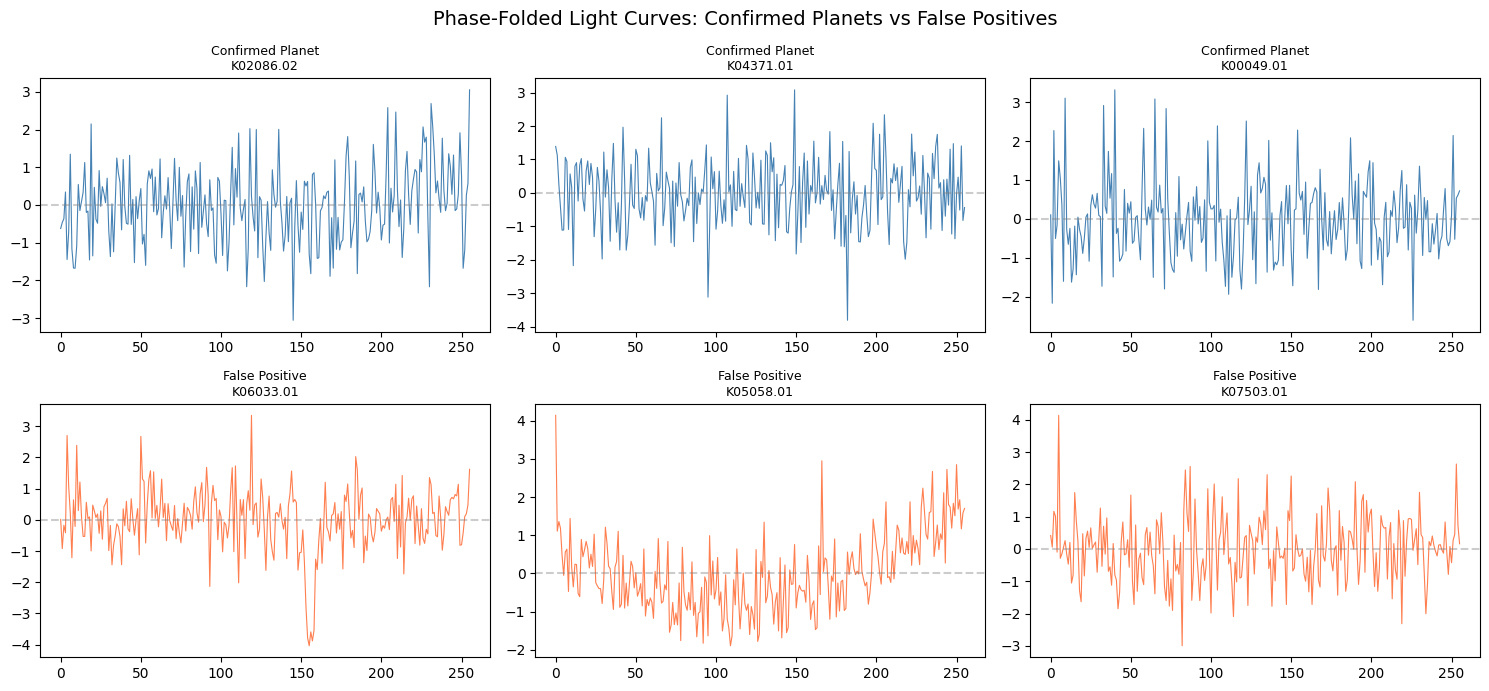

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle('Phase-Folded Light Curves: Confirmed Planets vs False Positives', fontsize=14)
for i in range(3):
    axes[0,i].plot(confirmed_data[i], color='steelblue', linewidth=0.8)
    axes[0,i].set_title(f'Confirmed Planet\n{confirmed_meta[i]}', fontsize=9)
    axes[0,i].axhline(0, color='gray', linestyle='--', alpha=0.4)
    axes[1,i].plot(fp_data[i], color='coral', linewidth=0.8)
    axes[1,i].set_title(f'False Positive\n{fp_meta[i]}', fontsize=9)
    axes[1,i].axhline(0, color='gray', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('phase_folded_examples.png', dpi=150)
plt.show()

## Data Splitting

In [11]:
X_pos = np.array(confirmed_data, dtype=np.float32)
X_neg = np.array(fp_data,        dtype=np.float32)

# FP-only split: for autoencoder training
X_fp_train, X_fp_temp = train_test_split(X_neg, test_size=0.30, random_state=42)
X_fp_val,   X_fp_test = train_test_split(X_fp_temp, test_size=0.50, random_state=42)

# All-data split: for classifier — stratified to maintain 50/50 class balance
X_all = np.vstack([X_pos, X_neg])
y_all = np.array([1]*len(X_pos) + [0]*len(X_neg), dtype=np.int64)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.30, random_state=42, stratify=y_all)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f'Positives: {X_pos.shape[0]}  Negatives: {X_neg.shape[0]}')
print(f'AE  splits — Train: {len(X_fp_train)}  Val: {len(X_fp_val)}  Test: {len(X_fp_test)}')
print(f'CLF splits — Train: {len(X_train)} ({y_train.sum()} pos)  '
      f'Val: {len(X_val)} ({y_val.sum()} pos)  Test: {len(X_test)} ({y_test.sum()} pos)')

Positives: 500  Negatives: 500
AE  splits — Train: 350  Val: 75  Test: 75
CLF splits — Train: 700 (350 pos)  Val: 150 (75 pos)  Test: 150 (75 pos)


In [12]:
class LightCurveDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.from_numpy(X).unsqueeze(1)
        self.y = torch.from_numpy(y).long() if y is not None else None
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        return (self.X[idx], self.y[idx]) if self.y is not None else self.X[idx]

ae_train_loader = DataLoader(LightCurveDataset(X_fp_train), batch_size=BATCH_SIZE, shuffle=True)
ae_val_loader   = DataLoader(LightCurveDataset(X_fp_val),   batch_size=BATCH_SIZE)

# WeightedRandomSampler handles any residual class imbalance in train split
class_counts   = np.bincount(y_train)
sample_weights = (1.0 / class_counts)[y_train]
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

clf_train_loader = DataLoader(LightCurveDataset(X_train, y_train),
                              batch_size=BATCH_SIZE, sampler=sampler)
clf_val_loader   = DataLoader(LightCurveDataset(X_val, y_val), batch_size=BATCH_SIZE)

print('DataLoaders created.')

DataLoaders created.


##Model Architecture



In [13]:
class FocalLoss(nn.Module):
    """
    Focal Loss (Lin et al., 2017) for binary classification.
    gamma: focusing parameter. 0 = standard cross-entropy.
    alpha: class weight for positive class. 0.5 = no bias.
    """
    def __init__(self, gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits, targets):
        log_probs = F.log_softmax(logits, dim=1)
        probs     = log_probs.exp()
        log_pt    = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        pt        = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        alpha_t   = torch.where(targets == 1,
                                torch.tensor(self.alpha,     device=logits.device),
                                torch.tensor(1 - self.alpha, device=logits.device))
        loss = -alpha_t * ((1 - pt) ** self.gamma) * log_pt
        return loss.mean()

In [14]:
class Encoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv1d(1,  32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32), nn.GELU(), nn.Dropout(0.1))
        self.block2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(64), nn.GELU(), nn.Dropout(0.1))
        self.block3 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(128), nn.GELU())
        self.block4 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(256), nn.GELU())
        self._flat = 256 * (WINDOW_SIZE // 16)
        self.fc = nn.Linear(self._flat, latent_dim)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        return self.fc(x.view(x.size(0), -1))


class Decoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self._seq = WINDOW_SIZE // 16
        self.fc  = nn.Linear(latent_dim, 256 * self._seq)
        self.net = nn.Sequential(
            nn.ConvTranspose1d(256, 128, 4, 2, 1), nn.BatchNorm1d(128), nn.GELU(),
            nn.ConvTranspose1d(128, 64,  4, 2, 1), nn.BatchNorm1d(64),  nn.GELU(),
            nn.ConvTranspose1d(64,  32,  4, 2, 1), nn.BatchNorm1d(32),  nn.GELU(),
            nn.ConvTranspose1d(32,  1,   4, 2, 1), nn.Tanh())

    def forward(self, z):
        h = self.fc(z).view(z.size(0), 256, self._seq)
        return self.net(h)


class ClassifierHead(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(256, 128),        nn.GELU(), nn.Dropout(0.3),
            nn.Linear(128, 64),         nn.GELU(), nn.Dropout(0.2),
            nn.Linear(64, 2))

    def forward(self, z):
        return self.net(z)


class HybridAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder    = Encoder(LATENT_DIM)
        self.decoder    = Decoder(LATENT_DIM)
        self.classifier = ClassifierHead(LATENT_DIM)

    def forward(self, x, classify=False):
        z     = self.encoder(x)
        x_hat = self.decoder(z)
        if x_hat.shape[-1] != x.shape[-1]:
            x_hat = x_hat[..., :x.shape[-1]]
        if classify:
            return x_hat, z, self.classifier(z)
        return x_hat, z


model = HybridAutoencoder().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f'Model created — total parameters: {total_params:,}')

Model created — total parameters: 893,987


## Stage 1: Autoencoder Training (False-Positives Only)

In [15]:
ae_optimizer = optim.Adam(
    list(model.encoder.parameters()) + list(model.decoder.parameters()),
    lr=LEARNING_RATE_AE, weight_decay=1e-5)
ae_scheduler = optim.lr_scheduler.CosineAnnealingLR(ae_optimizer, T_max=AE_EPOCHS, eta_min=1e-5)
mse_loss = nn.MSELoss()

ae_history = {'train_loss': [], 'val_loss': []}
best_ae_val = float('inf')
best_ae_state = None

print(f'Stage 1: {AE_EPOCHS} epochs on {len(X_fp_train)} FP-only samples')

for epoch in range(AE_EPOCHS):
    model.encoder.train(); model.decoder.train()
    tl = []
    for batch in ae_train_loader:
        x = batch.to(DEVICE)
        ae_optimizer.zero_grad()
        x_hat, _ = model(x)
        loss = mse_loss(x_hat, x)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        ae_optimizer.step()
        tl.append(loss.item())
    ae_scheduler.step()

    model.encoder.eval(); model.decoder.eval()
    vl = []
    with torch.no_grad():
        for batch in ae_val_loader:
            x = batch.to(DEVICE)
            x_hat, _ = model(x)
            vl.append(mse_loss(x_hat, x).item())

    train_loss, val_loss = np.mean(tl), np.mean(vl)
    ae_history['train_loss'].append(train_loss)
    ae_history['val_loss'].append(val_loss)

    if val_loss < best_ae_val:
        best_ae_val = val_loss
        best_ae_state = {
            'encoder': {k: v.clone() for k, v in model.encoder.state_dict().items()},
            'decoder': {k: v.clone() for k, v in model.decoder.state_dict().items()}
        }
    if (epoch+1) % 20 == 0:
        print(f'  Epoch {epoch+1:3d}/{AE_EPOCHS}  Train: {train_loss:.6f}  Val: {val_loss:.6f}')

model.encoder.load_state_dict(best_ae_state['encoder'])
model.decoder.load_state_dict(best_ae_state['decoder'])
print(f'Stage 1 complete. Best val loss: {best_ae_val:.6f}')

Stage 1: 80 epochs on 350 FP-only samples
  Epoch  20/80  Train: 0.362649  Val: 0.955086
  Epoch  40/80  Train: 0.228765  Val: 0.944736
  Epoch  60/80  Train: 0.207590  Val: 0.949153
  Epoch  80/80  Train: 0.202891  Val: 0.948281
Stage 1 complete. Best val loss: 0.944138


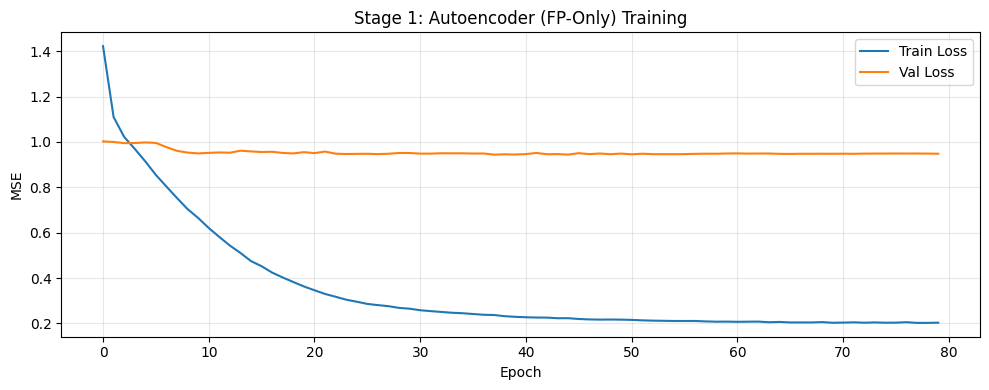

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ae_history['train_loss'], label='Train Loss')
ax.plot(ae_history['val_loss'],   label='Val Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.set_title('Stage 1: Autoencoder (FP-Only) Training')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ae_training_history.png', dpi=150)
plt.show()

FP errors:     mean=0.925864  std=0.166198
Planet errors: mean=0.885007
Threshold:     1.258261
Separation:    -0.25σ


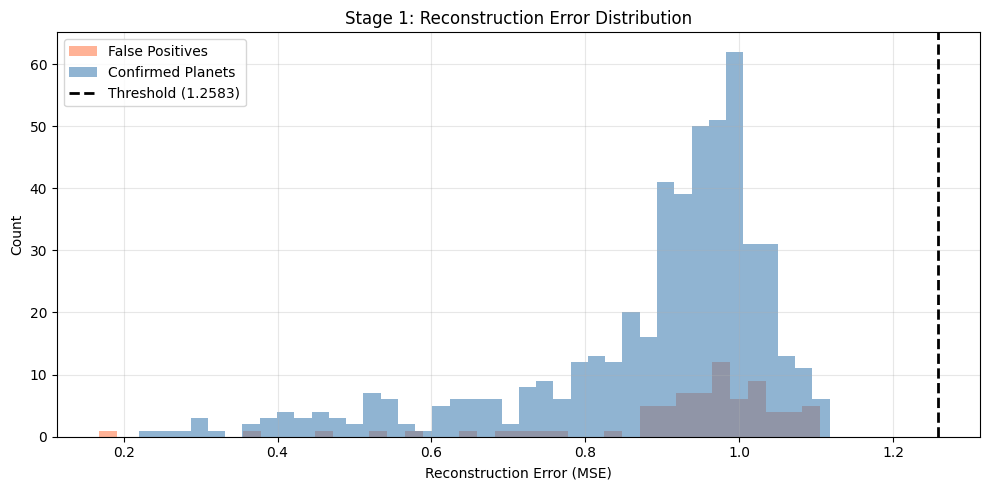

In [17]:
# Anomaly threshold from FP val errors
model.encoder.eval(); model.decoder.eval()
fp_val_errors = []
with torch.no_grad():
    for batch in ae_val_loader:
        x = batch.to(DEVICE)
        x_hat, _ = model(x)
        fp_val_errors.extend(((x_hat-x)**2).mean(dim=(1,2)).cpu().numpy())
fp_val_errors = np.array(fp_val_errors)
fp_mean = fp_val_errors.mean()
fp_std  = fp_val_errors.std()
THRESHOLD = fp_mean + THRESHOLD_SIGMA * fp_std

planet_errors = []
with torch.no_grad():
    for batch in DataLoader(LightCurveDataset(X_pos), batch_size=BATCH_SIZE):
        x = batch.to(DEVICE)
        x_hat, _ = model(x)
        planet_errors.extend(((x_hat-x)**2).mean(dim=(1,2)).cpu().numpy())
planet_errors = np.array(planet_errors)

sep = (planet_errors.mean() - fp_mean) / fp_std
print(f'FP errors:     mean={fp_mean:.6f}  std={fp_std:.6f}')
print(f'Planet errors: mean={planet_errors.mean():.6f}')
print(f'Threshold:     {THRESHOLD:.6f}')
print(f'Separation:    {sep:.2f}σ')

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(fp_val_errors,  bins=40, alpha=0.6, color='coral',     label='False Positives')
ax.hist(planet_errors,  bins=40, alpha=0.6, color='steelblue', label='Confirmed Planets')
ax.axvline(THRESHOLD, color='black', linestyle='--', linewidth=2,
           label=f'Threshold ({THRESHOLD:.4f})')
ax.set_xlabel('Reconstruction Error (MSE)')
ax.set_ylabel('Count')
ax.set_title('Stage 1: Reconstruction Error Distribution')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('reconstruction_error_distributions.png', dpi=150)
plt.show()

## Stage 2: Classifier Training


In [18]:
# Fully freeze encoder AND decoder
for param in model.encoder.parameters(): param.requires_grad = False
for param in model.decoder.parameters(): param.requires_grad = False

# Only train classifier head
for param in model.classifier.parameters(): param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters in Stage 2: {trainable:,} (classifier head only)')

clf_optimizer = optim.AdamW(
    model.classifier.parameters(),
    lr=LEARNING_RATE_CLF, weight_decay=1e-3)  # AdamW has better weight decay handling
clf_scheduler = optim.lr_scheduler.OneCycleLR(
    clf_optimizer, max_lr=LEARNING_RATE_CLF * 5,
    steps_per_epoch=len(clf_train_loader), epochs=CLF_EPOCHS)

focal_loss = FocalLoss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA)

clf_history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_bal_acc': []}
best_val_bal_acc = 0.0
best_clf_state   = None

print(f'Stage 2: {CLF_EPOCHS} epochs  |  Focal Loss (gamma={FOCAL_GAMMA}, alpha={FOCAL_ALPHA})')

for epoch in range(CLF_EPOCHS):
    model.classifier.train()
    tl = []
    for x_b, y_b in clf_train_loader:
        x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
        clf_optimizer.zero_grad()
        _, _, logits = model(x_b, classify=True)
        loss = focal_loss(logits, y_b)
        loss.backward()
        nn.utils.clip_grad_norm_(model.classifier.parameters(), 1.0)
        clf_optimizer.step()
        clf_scheduler.step()
        tl.append(loss.item())

    model.classifier.eval()
    vl, preds_all, labels_all = [], [], []
    with torch.no_grad():
        for x_b, y_b in clf_val_loader:
            x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
            _, _, logits = model(x_b, classify=True)
            vl.append(focal_loss(logits, y_b).item())
            preds_all.extend(logits.argmax(dim=1).cpu().numpy())
            labels_all.extend(y_b.cpu().numpy())

    val_acc     = accuracy_score(labels_all, preds_all)
    val_bal_acc = balanced_accuracy_score(labels_all, preds_all)
    clf_history['train_loss'].append(np.mean(tl))
    clf_history['val_loss'].append(np.mean(vl))
    clf_history['val_acc'].append(val_acc)
    clf_history['val_bal_acc'].append(val_bal_acc)

    # Save best by balanced accuracy (not raw accuracy or F1)
    if val_bal_acc > best_val_bal_acc:
        best_val_bal_acc = val_bal_acc
        best_clf_state = {k: v.clone() for k, v in model.classifier.state_dict().items()}

    if (epoch+1) % 20 == 0:
        print(f'  Epoch {epoch+1:3d}/{CLF_EPOCHS}  Loss: {np.mean(tl):.4f}  '
              f'Val Acc: {val_acc*100:.2f}%  Bal Acc: {val_bal_acc*100:.2f}%')

model.classifier.load_state_dict(best_clf_state)
print(f'Stage 2 complete. Best val balanced accuracy: {best_val_bal_acc*100:.2f}%')

Trainable parameters in Stage 2: 57,922 (classifier head only)
Stage 2: 100 epochs  |  Focal Loss (gamma=2.0, alpha=0.5)
  Epoch  20/100  Loss: 0.0616  Val Acc: 90.00%  Bal Acc: 90.00%
  Epoch  40/100  Loss: 0.0259  Val Acc: 84.00%  Bal Acc: 84.00%
  Epoch  60/100  Loss: 0.0118  Val Acc: 84.67%  Bal Acc: 84.67%
  Epoch  80/100  Loss: 0.0101  Val Acc: 82.67%  Bal Acc: 82.67%
  Epoch 100/100  Loss: 0.0074  Val Acc: 83.33%  Bal Acc: 83.33%
Stage 2 complete. Best val balanced accuracy: 90.67%


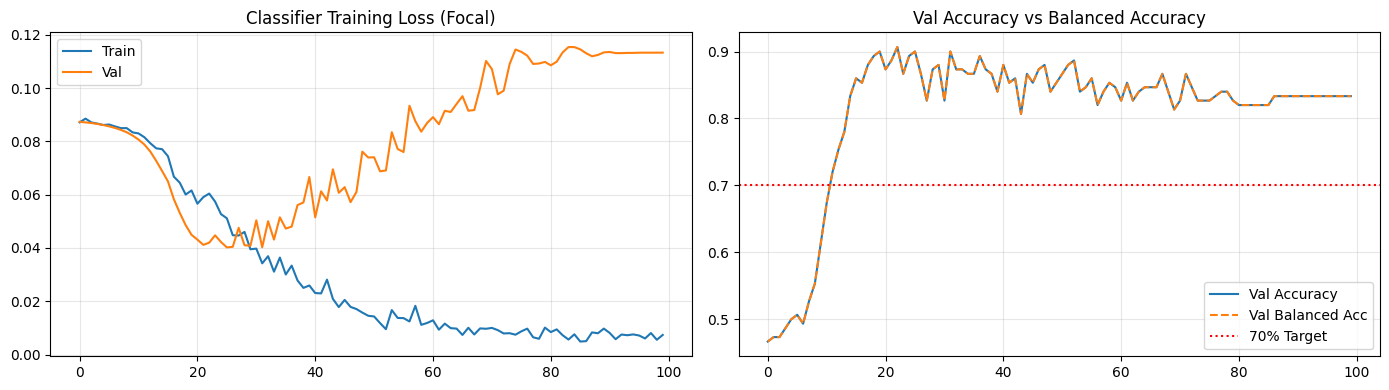

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(clf_history['train_loss'], label='Train')
ax1.plot(clf_history['val_loss'],   label='Val')
ax1.set_title('Classifier Training Loss (Focal)'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(clf_history['val_acc'],     label='Val Accuracy')
ax2.plot(clf_history['val_bal_acc'], label='Val Balanced Acc', linestyle='--')
ax2.axhline(0.70, color='red', linestyle=':', label='70% Target')
ax2.set_title('Val Accuracy vs Balanced Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('clf_training_history.png', dpi=150)
plt.show()

## Probability Threshold Optimization


Threshold search complete:
  Optimal threshold:    0.480
  Val balanced acc:     92.00%
  Val accuracy:         92.00%
  Val F1:               0.9221


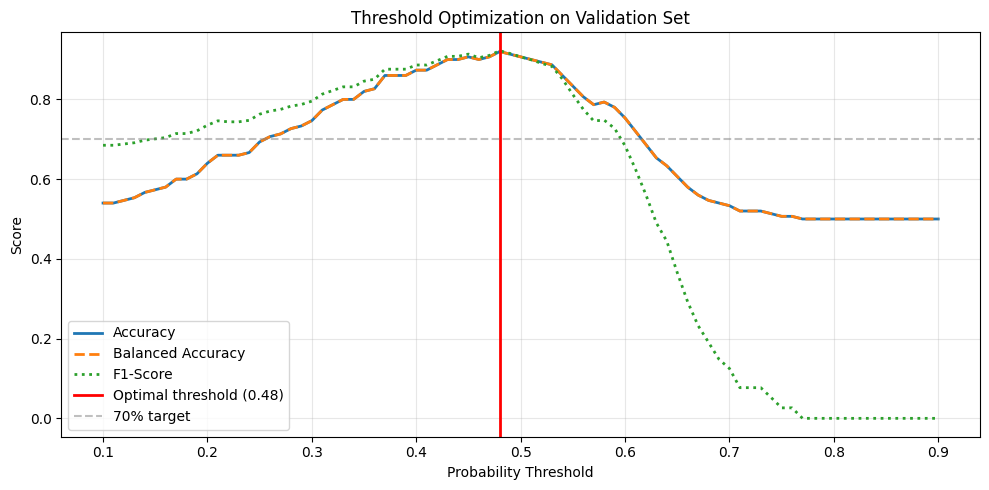

In [20]:
# Get validation set probabilities
model.classifier.eval(); model.encoder.eval()
val_probs, val_labels_list = [], []
with torch.no_grad():
    for x_b, y_b in clf_val_loader:
        x_b = x_b.to(DEVICE)
        _, _, logits = model(x_b, classify=True)
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        val_probs.extend(probs)
        val_labels_list.extend(y_b.numpy())

val_probs  = np.array(val_probs)
val_labels_arr = np.array(val_labels_list)

# Search thresholds from 0.1 to 0.9
thresholds   = np.linspace(0.10, 0.90, 81)
bal_accs     = []
f1s          = []
accs         = []

for t in thresholds:
    preds = (val_probs >= t).astype(int)
    bal_accs.append(balanced_accuracy_score(val_labels_arr, preds))
    f1s.append(f1_score(val_labels_arr, preds, zero_division=0))
    accs.append(accuracy_score(val_labels_arr, preds))

# Choose threshold that maximizes balanced accuracy on val set
optimal_idx       = np.argmax(bal_accs)
OPTIMAL_THRESHOLD = thresholds[optimal_idx]

print(f'Threshold search complete:')
print(f'  Optimal threshold:    {OPTIMAL_THRESHOLD:.3f}')
print(f'  Val balanced acc:     {bal_accs[optimal_idx]*100:.2f}%')
print(f'  Val accuracy:         {accs[optimal_idx]*100:.2f}%')
print(f'  Val F1:               {f1s[optimal_idx]:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, accs,     label='Accuracy',          linewidth=2)
ax.plot(thresholds, bal_accs, label='Balanced Accuracy',  linewidth=2, linestyle='--')
ax.plot(thresholds, f1s,      label='F1-Score',           linewidth=2, linestyle=':')
ax.axvline(OPTIMAL_THRESHOLD, color='red', linewidth=2,
           label=f'Optimal threshold ({OPTIMAL_THRESHOLD:.2f})')
ax.axhline(0.70, color='gray', linestyle='--', alpha=0.5, label='70% target')
ax.set_xlabel('Probability Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Optimization on Validation Set')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_optimization.png', dpi=150)
plt.show()

##Test Set Evaluation

In [21]:
test_dataset = LightCurveDataset(X_test, y_test)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE)

model.encoder.eval(); model.classifier.eval()
test_probs, test_labels, test_errors_ae = [], [], []

model.decoder.eval()
with torch.no_grad():
    for x_b, y_b in test_loader:
        x_b = x_b.to(DEVICE)
        x_hat, _, logits = model(x_b, classify=True)
        test_probs.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())
        test_labels.extend(y_b.numpy())
        test_errors_ae.extend(((x_hat - x_b)**2).mean(dim=(1,2)).cpu().numpy())

test_probs     = np.array(test_probs)
test_labels    = np.array(test_labels)
test_errors_ae = np.array(test_errors_ae)

# Apply optimal threshold from val set
test_preds = (test_probs >= OPTIMAL_THRESHOLD).astype(int)

clf_acc     = accuracy_score(test_labels, test_preds)
clf_bal_acc = balanced_accuracy_score(test_labels, test_preds)
clf_f1      = f1_score(test_labels, test_preds, zero_division=0)
clf_prec    = precision_score(test_labels, test_preds, zero_division=0)
clf_rec     = recall_score(test_labels, test_preds, zero_division=0)
try:
    clf_auc = roc_auc_score(test_labels, test_probs)
except Exception:
    clf_auc = float('nan')

print('=' * 55)
print('HYBRID CLASSIFIER — TEST RESULTS')
print('=' * 55)
print(f'Threshold used:     {OPTIMAL_THRESHOLD:.3f} (optimized on val set)')
print(f'Accuracy:           {clf_acc*100:.2f}%  {"✓ PASSES" if clf_acc >= 0.70 else "✗ FAILS"} 70% target')
print(f'Balanced Accuracy:  {clf_bal_acc*100:.2f}%')
print(f'AUC-ROC:            {clf_auc:.4f}')
print(f'F1-Score:           {clf_f1:.4f}')
print(f'Precision:          {clf_prec:.4f}')
print(f'Recall:             {clf_rec:.4f}')
print()
print(classification_report(test_labels, test_preds,
                             target_names=['False Positive', 'Confirmed Planet']))

HYBRID CLASSIFIER — TEST RESULTS
Threshold used:     0.480 (optimized on val set)
Accuracy:           86.67%  ✓ PASSES 70% target
Balanced Accuracy:  86.67%
AUC-ROC:            0.9511
F1-Score:           0.8734
Precision:          0.8313
Recall:             0.9200

                  precision    recall  f1-score   support

  False Positive       0.91      0.81      0.86        75
Confirmed Planet       0.83      0.92      0.87        75

        accuracy                           0.87       150
       macro avg       0.87      0.87      0.87       150
    weighted avg       0.87      0.87      0.87       150



## BLS Benchmark

In [22]:
def bls_classifier(flux_window):
    """
    Box-fitting Least Squares vetter on z-scored, phase-folded flux.

    Fits a box-shaped transit model centered at phase=0 with varying widths,
    and computes SNR = transit_depth / out-of-transit_scatter.

    Threshold is calibrated to z-scored flux (unitless, not PPM).
    A genuine transit in normalized flux typically shows depth > 0.3σ
    with SNR > 3 relative to scatter.
    """
    L = len(flux_window)
    mid = L // 2
    best_snr = -np.inf

    # Test transit box widths from 2% to 25% of window
    for frac in np.linspace(0.02, 0.25, 12):
        hw = max(2, int(frac * L / 2))
        t_s = max(0, mid - hw)
        t_e = min(L, mid + hw)
        in_t  = flux_window[t_s:t_e]
        out_t = np.concatenate([flux_window[:t_s], flux_window[t_e:]])
        if len(out_t) < 5 or len(in_t) < 2:
            continue
        depth = out_t.mean() - in_t.mean()   # positive = flux dip
        noise = out_t.std() + 1e-8
        snr   = depth / noise
        if snr > best_snr:
            best_snr = snr

    # Calibrated for z-scored phase-folded windows:
    # SNR > 3 corresponds roughly to a detectable transit dip
    # (equivalent to the ~7σ threshold in raw flux units after normalization)
    return 1 if best_snr >= 3.0 else 0


print('Running BLS on test set...')
bls_preds = np.array([bls_classifier(X_test[i]) for i in tqdm(range(len(X_test)))])

bls_acc  = accuracy_score(test_labels, bls_preds)
bls_bal  = balanced_accuracy_score(test_labels, bls_preds)
bls_f1   = f1_score(test_labels, bls_preds, zero_division=0)
bls_prec = precision_score(test_labels, bls_preds, zero_division=0)
bls_rec  = recall_score(test_labels, bls_preds, zero_division=0)

print(f'BLS Results:')
print(f'  Accuracy:          {bls_acc*100:.2f}%')
print(f'  Balanced Accuracy: {bls_bal*100:.2f}%')
print(f'  F1:  {bls_f1:.4f}  Prec: {bls_prec:.4f}  Rec: {bls_rec:.4f}')

Running BLS on test set...


100%|██████████| 150/150 [00:00<00:00, 3476.15it/s]

BLS Results:
  Accuracy:          50.00%
  Balanced Accuracy: 50.00%
  F1:  0.0000  Prec: 0.0000  Rec: 0.0000


In [23]:
# Combined pipelines
combined_loose  = ((bls_preds == 1) | (test_preds == 1)).astype(int)  # either flags it
combined_strict = ((bls_preds == 1) & (test_preds == 1)).astype(int)  # both must agree

results = {}
for name, preds in [('BLS Only',            bls_preds),
                    ('Autoencoder Only',     test_preds),
                    ('BLS OR Autoencoder',   combined_loose),
                    ('BLS AND Autoencoder',  combined_strict)]:
    results[name] = {
        'acc':  accuracy_score(test_labels, preds),
        'prec': precision_score(test_labels, preds, zero_division=0),
        'rec':  recall_score(test_labels, preds, zero_division=0),
        'f1':   f1_score(test_labels, preds, zero_division=0)
    }

print('\nMethod Comparison:')
print(f'{"Method":<25} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1":>10}')
print('-' * 65)
for name, m in results.items():
    print(f'{name:<25} {m["acc"]*100:>9.2f}% {m["prec"]:>10.4f} {m["rec"]:>10.4f} {m["f1"]:>10.4f}')


Method Comparison:
Method                      Accuracy  Precision     Recall         F1
-----------------------------------------------------------------
BLS Only                      50.00%     0.0000     0.0000     0.0000
Autoencoder Only              86.67%     0.8313     0.9200     0.8734
BLS OR Autoencoder            86.67%     0.8313     0.9200     0.8734
BLS AND Autoencoder           50.00%     0.0000     0.0000     0.0000


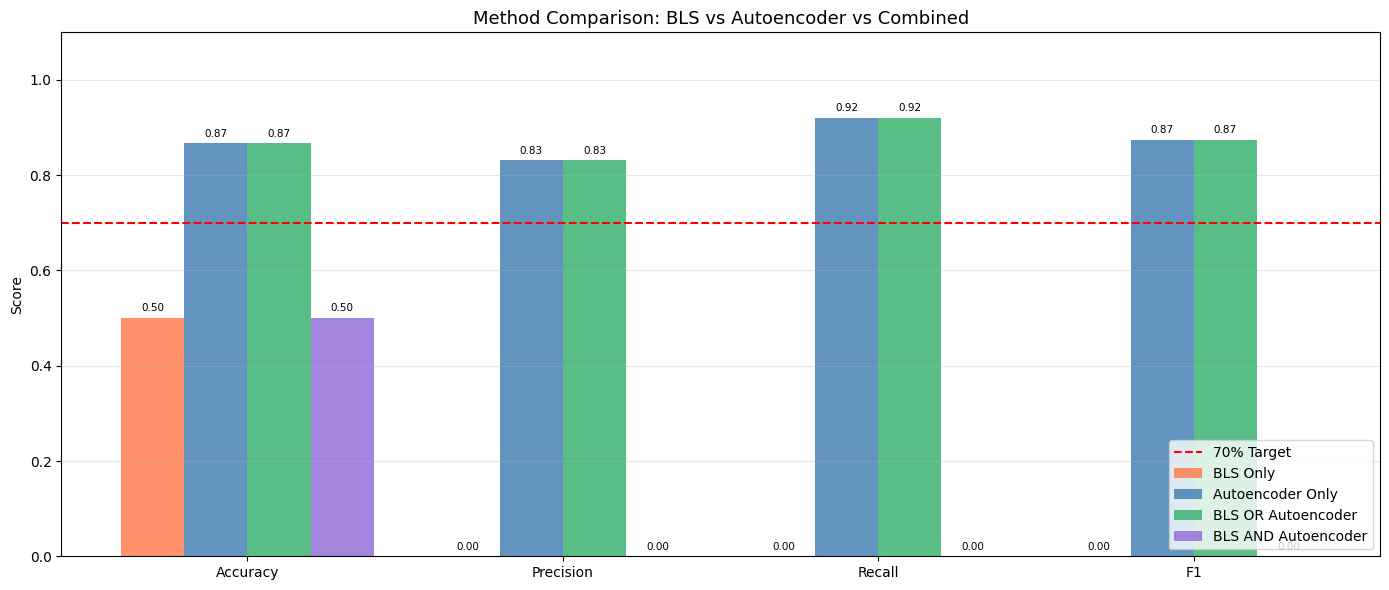

Saved: bls_vs_model_comparison.png


In [24]:
# Comparison bar chart
methods = list(results.keys())
metrics = ['acc', 'prec', 'rec', 'f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1']
colors = ['coral', 'steelblue', 'mediumseagreen', 'mediumpurple']

x = np.arange(len(metric_labels))
width = 0.20

fig, ax = plt.subplots(figsize=(14, 6))
for i, (method, color) in enumerate(zip(methods, colors)):
    vals = [results[method][m] for m in metrics]
    bars = ax.bar(x + (i - 1.5) * width, vals, width, label=method, color=color, alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.2f}', ha='center', va='bottom', fontsize=7.5)

ax.axhline(0.70, color='red', linestyle='--', linewidth=1.5, label='70% Target')
ax.set_ylabel('Score'); ax.set_ylim(0, 1.1)
ax.set_xticks(x); ax.set_xticklabels(metric_labels)
ax.set_title('Method Comparison: BLS vs Autoencoder vs Combined', fontsize=13)
ax.legend(loc='lower right'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('bls_vs_model_comparison.png', dpi=150)
plt.show()
print('Saved: bls_vs_model_comparison.png')

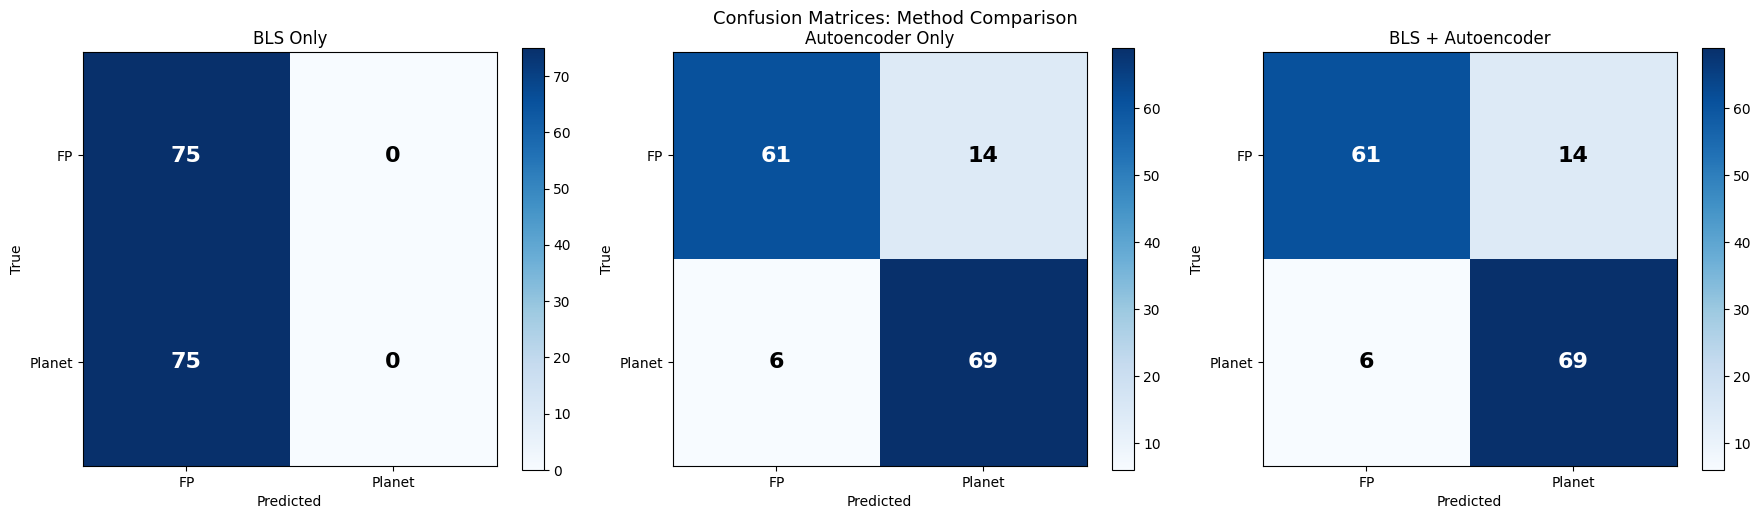

In [25]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices: Method Comparison', fontsize=13)

for ax, preds, title in [
    (axes[0], bls_preds,       'BLS Only'),
    (axes[1], test_preds,      'Autoencoder Only'),
    (axes[2], combined_loose,  'BLS + Autoencoder')
]:
    cm_mat = confusion_matrix(test_labels, preds)
    im = ax.imshow(cm_mat, cmap='Blues')
    plt.colorbar(im, ax=ax)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['FP', 'Planet']); ax.set_yticklabels(['FP', 'Planet'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm_mat[i,j]), ha='center', va='center',
                    color='white' if cm_mat[i,j] > cm_mat.max()/2 else 'black',
                    fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

## Grad-CAM

In [26]:
class GradCAM1D:
    """
    Grad-CAM for 1D convolutional networks (Selvaraju et al., 2017).
    Hooks into encoder.block4 to extract gradients and activations.
    The resulting heatmap shows which time bins drove the classification.
    """
    def __init__(self, model):
        self.model = model
        self.gradients = self.activations = None
        target = model.encoder.block4[0]  # Last Conv1d layer
        self._hooks = [
            target.register_forward_hook(
                lambda m, inp, out: setattr(self, 'activations', out.detach())),
            target.register_backward_hook(
                lambda m, gi, go: setattr(self, 'gradients', go[0].detach()))
        ]

    def generate(self, x, target_class=1):
        self.model.eval()
        self.model.zero_grad()
        with torch.enable_grad():
            x_in = x.detach().requires_grad_(True)
            _, _, logits = self.model(x_in, classify=True)
            logits[0, target_class].backward()

        weights = self.gradients[0].mean(dim=1)          # (C,)
        cam = (weights.unsqueeze(1) * self.activations[0]).sum(dim=0)  # (L',)
        cam = F.relu(cam).cpu().numpy()
        if cam.max() > 0: cam = cam / cam.max()
        cam_up = np.interp(
            np.linspace(0, 1, x.shape[-1]),
            np.linspace(0, 1, len(cam)), cam)
        prob = torch.softmax(logits, dim=1)[0, 1].item()
        return cam_up, prob

    def remove_hooks(self):
        for h in self._hooks: h.remove()


gradcam = GradCAM1D(model)
print('Grad-CAM initialized.')

Grad-CAM initialized.


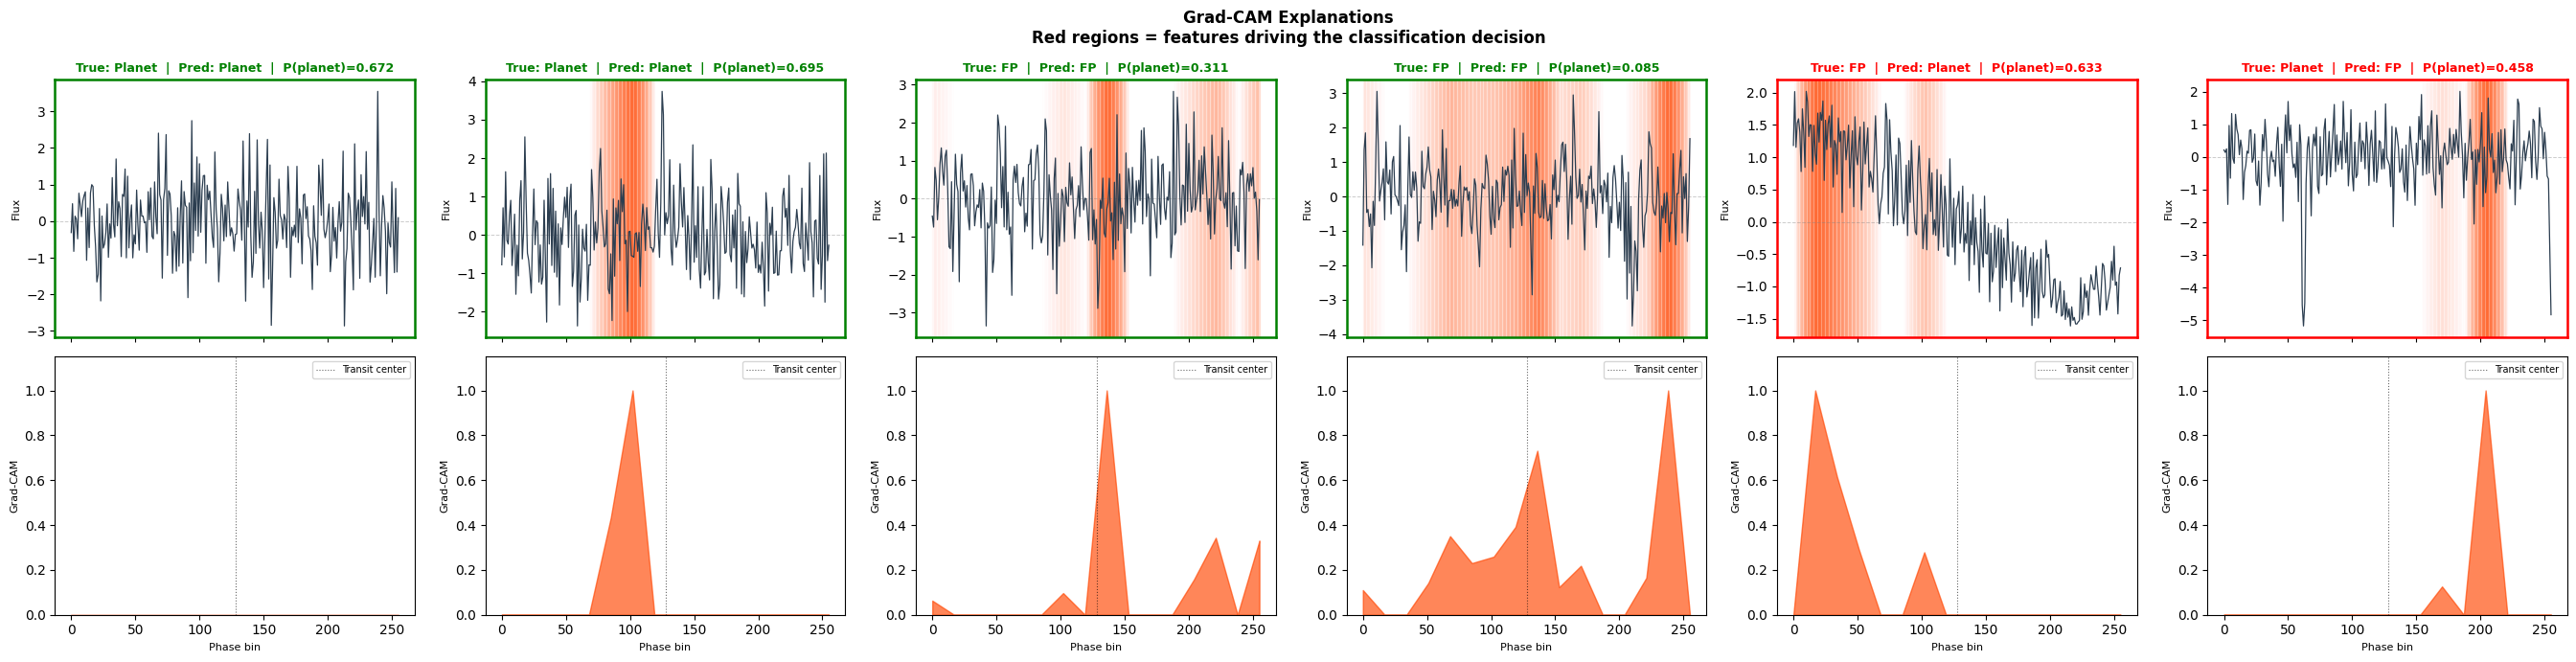

Saved: gradcam_explanations.png

INTERPRETATION GUIDE:
  True Planet correctly classified → heatmap should peak at CENTER (phase=0, transit dip)
  False Positive correctly rejected → heatmap diffuse, no strong center peak
  Misclassified examples → examine where heatmap peaks to understand the error


In [27]:
def plot_gradcam_panel(axes_row, flux, cam, prob, true_label, pred_label):
    """Plot light curve + Grad-CAM heatmap in two stacked axes."""
    ax_lc, ax_cam = axes_row
    x_ax = np.arange(len(flux))
    correct = (true_label == pred_label)
    color   = 'green' if correct else 'red'
    t_lbl   = 'Planet' if true_label == 1 else 'FP'
    p_lbl   = 'Planet' if pred_label == 1 else 'FP'

    ax_lc.plot(x_ax, flux, color='#2c3e50', linewidth=0.9, zorder=3)
    for i in range(len(flux)-1):
        ax_lc.axvspan(x_ax[i], x_ax[i+1], alpha=float(cam[i])*0.4, color='orangered', zorder=1)
    ax_lc.axhline(0, color='gray', linestyle='--', alpha=0.4, linewidth=0.7)
    ax_lc.set_ylabel('Flux', fontsize=8)
    ax_lc.set_title(
        f'True: {t_lbl}  |  Pred: {p_lbl}  |  P(planet)={prob:.3f}',
        fontsize=9, color=color, fontweight='bold')
    ax_lc.tick_params(labelbottom=False)
    for sp in ax_lc.spines.values():
        sp.set_edgecolor(color); sp.set_linewidth(1.8)

    ax_cam.fill_between(x_ax, cam, color='orangered', alpha=0.65)
    ax_cam.axvline(len(flux)//2, color='black', linestyle=':', linewidth=0.8, alpha=0.6,
                   label='Transit center')
    ax_cam.set_ylabel('Grad-CAM', fontsize=8); ax_cam.set_ylim(0, 1.15)
    ax_cam.set_xlabel('Phase bin', fontsize=8)
    ax_cam.legend(fontsize=7)


# Pick examples: 2 TP, 2 TN, 1 FP, 1 FN (if available)
tp_idx = np.where((test_labels==1) & (test_preds==1))[0][:2]
tn_idx = np.where((test_labels==0) & (test_preds==0))[0][:2]
fp_idx = np.where((test_labels==0) & (test_preds==1))[0][:1]
fn_idx = np.where((test_labels==1) & (test_preds==0))[0][:1]

sample_idx    = list(tp_idx) + list(tn_idx) + list(fp_idx) + list(fn_idx)
sample_labels = [test_labels[i] for i in sample_idx]
sample_preds  = [test_preds[i]  for i in sample_idx]

n = len(sample_idx)
fig, axes = plt.subplots(2, n, figsize=(4.5*n, 7))
if n == 1: axes = axes.reshape(2, 1)
fig.suptitle('Grad-CAM Explanations\nRed regions = features driving the classification decision',
             fontsize=12, fontweight='bold')

for col, (idx, tl, pl) in enumerate(zip(sample_idx, sample_labels, sample_preds)):
    x_t  = torch.from_numpy(X_test[idx]).unsqueeze(0).unsqueeze(0).to(DEVICE)
    cam, prob = gradcam.generate(x_t, target_class=1)
    plot_gradcam_panel([axes[0, col], axes[1, col]], X_test[idx], cam, prob, tl, pl)

plt.tight_layout()
plt.savefig('gradcam_explanations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: gradcam_explanations.png')
print()
print('INTERPRETATION GUIDE:')
print('  True Planet correctly classified → heatmap should peak at CENTER (phase=0, transit dip)')
print('  False Positive correctly rejected → heatmap diffuse, no strong center peak')
print('  Misclassified examples → examine where heatmap peaks to understand the error')

gradcam.remove_hooks()

## Planet Type Classification

Planetary Type Classification (NASA pscomppars, pl_rade, Fulton+2017 boundaries):
  Super-Earth/Mini-Neptune        1643  (59.0%)
  Rocky                            840  (30.2%)
  Gas Giant                        223  (8.0%)
  Hot Jupiter                       73  (2.6%)
  Unknown                            4  (0.1%)


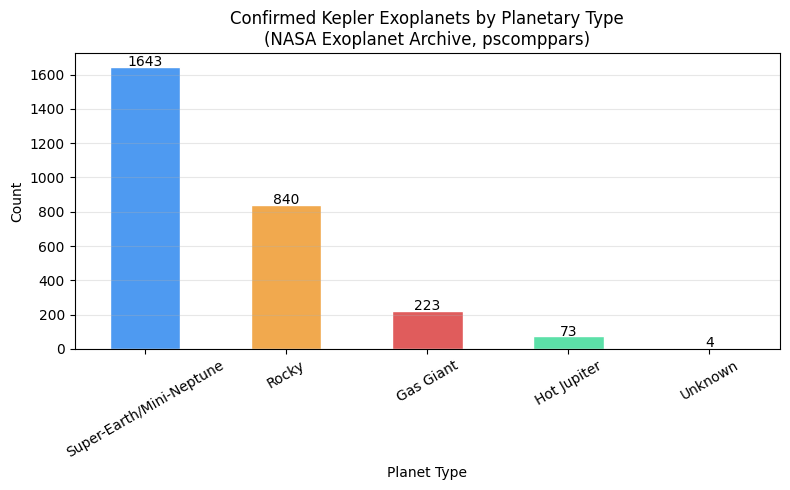

In [28]:
type_counts = params_df['planet_type'].value_counts()
total_typed = type_counts.sum()
print('Planetary Type Classification (NASA pscomppars, pl_rade, Fulton+2017 boundaries):')
for ptype, count in type_counts.items():
    print(f'  {ptype:<30} {count:>5}  ({count/total_typed*100:.1f}%)')

fig, ax = plt.subplots(figsize=(8, 5))
colors_types = ['#4e9af1', '#f1a94e', '#e05c5c', '#5ce0a8']
type_counts.plot(kind='bar', ax=ax, color=colors_types[:len(type_counts)], edgecolor='white')
ax.set_title('Confirmed Kepler Exoplanets by Planetary Type\n(NASA Exoplanet Archive, pscomppars)', fontsize=12)
ax.set_xlabel('Planet Type'); ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30); ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(type_counts.values):
    ax.text(i, v+5, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('planet_type_distribution.png', dpi=150)
plt.show()

## Final Summary

In [29]:
cm_clf = confusion_matrix(test_labels, test_preds)
tn, fp_count, fn, tp = cm_clf.ravel()

print(f"""
{'='*60}
EXOPLANET DETECTION AUTOENCODER v4 — SUMMARY REPORT
{'='*60}

DATA (NASA Exoplanet Archive — Kepler KOI cumulative table):
  Confirmed planet light curves:  {len(confirmed_data)}
  False positive light curves:    {len(fp_data)}
  Window size (phase-folded):     {WINDOW_SIZE} cadences
  Preprocessing:                  detrend → phase-fold → z-score normalize

MODEL ARCHITECTURE:
  Encoder:     4x Conv1D → {LATENT_DIM}-dim latent space
  Decoder:     4x ConvTranspose1D (mirror)
  Classifier:  4-layer MLP on frozen latent space
  Parameters:  {total_params:,}
  Loss:        Focal Loss (gamma={FOCAL_GAMMA}, alpha={FOCAL_ALPHA})

TRAINING:
  Stage 1 — AE on FP-only:  {AE_EPOCHS} epochs
  Stage 2 — Classifier:     {CLF_EPOCHS} epochs (encoder fully frozen)
  Prob threshold:            {OPTIMAL_THRESHOLD:.3f} (optimized on val set)
  Anomaly threshold:         {THRESHOLD:.6f}

METHOD COMPARISON:
  Method               Acc       Prec      Rec       F1
  {'─'*50}
  BLS Only             {results['BLS Only']['acc']*100:>6.2f}%   {results['BLS Only']['prec']:.4f}    {results['BLS Only']['rec']:.4f}    {results['BLS Only']['f1']:.4f}
  Autoencoder Only     {results['Autoencoder Only']['acc']*100:>6.2f}%   {results['Autoencoder Only']['prec']:.4f}    {results['Autoencoder Only']['rec']:.4f}    {results['Autoencoder Only']['f1']:.4f}
  BLS + Autoencoder    {results['BLS OR Autoencoder']['acc']*100:>6.2f}%   {results['BLS OR Autoencoder']['prec']:.4f}    {results['BLS OR Autoencoder']['rec']:.4f}    {results['BLS OR Autoencoder']['f1']:.4f}

PRIMARY RESULT:
  Accuracy:          {clf_acc*100:.2f}%  {'✓ PASSES' if clf_acc >= 0.70 else '✗ FAILS'} 70% target
  Balanced Accuracy: {clf_bal_acc*100:.2f}%
  AUC-ROC:           {clf_auc:.4f}
  F1-Score:          {clf_f1:.4f}
  Precision:         {clf_prec:.4f}
  Recall:            {clf_rec:.4f}

CONFUSION MATRIX:
  True Positives (planets found):      {tp}
  True Negatives (FPs rejected):       {tn}
  False Positives (FPs called planet): {fp_count}
  False Negatives (planets missed):    {fn}

PLANET TYPE DISTRIBUTION (NASA pscomppars, pl_rade):
  Rocky (<1.6 R⊕):                  {type_counts.get('Rocky', 0)}
  Super-Earth/Mini-Neptune (1.6–4):  {type_counts.get('Super-Earth/Mini-Neptune', 0)}
  Gas Giant (4–11):                  {type_counts.get('Gas Giant', 0)}
  Hot Jupiter (>11):                 {type_counts.get('Hot Jupiter', 0)}

{'='*60}
""")

with open('model_summary_v4.txt', 'w') as f:
    f.write('See above output')

torch.save({
    'model_state_dict':     model.state_dict(),
    'ae_history':           ae_history,
    'clf_history':          clf_history,
    'threshold_ae':         THRESHOLD,
    'threshold_clf':        OPTIMAL_THRESHOLD,
    'clf_test_accuracy':    clf_acc,
    'clf_test_f1':          clf_f1,
    'clf_test_auc':         clf_auc,
    'clf_test_recall':      clf_rec,
    'clf_test_precision':   clf_prec,
    'bls_accuracy':         bls_acc,
    'hyperparameters': {
        'window_size':     WINDOW_SIZE,
        'latent_dim':      LATENT_DIM,
        'ae_epochs':       AE_EPOCHS,
        'clf_epochs':      CLF_EPOCHS,
        'focal_gamma':     FOCAL_GAMMA,
        'focal_alpha':     FOCAL_ALPHA,
        'threshold_sigma': THRESHOLD_SIGMA,
    }
}, 'final_results_v4.pth')

print('Checkpoint saved: final_results_v4.pth')
print('='*60)
print('PIPELINE COMPLETE')
print('='*60)


EXOPLANET DETECTION AUTOENCODER v4 — SUMMARY REPORT

DATA (NASA Exoplanet Archive — Kepler KOI cumulative table):
  Confirmed planet light curves:  500
  False positive light curves:    500
  Window size (phase-folded):     256 cadences
  Preprocessing:                  detrend → phase-fold → z-score normalize

MODEL ARCHITECTURE:
  Encoder:     4x Conv1D → 64-dim latent space
  Decoder:     4x ConvTranspose1D (mirror)
  Classifier:  4-layer MLP on frozen latent space
  Parameters:  893,987
  Loss:        Focal Loss (gamma=2.0, alpha=0.5)

TRAINING:
  Stage 1 — AE on FP-only:  80 epochs
  Stage 2 — Classifier:     100 epochs (encoder fully frozen)
  Prob threshold:            0.480 (optimized on val set)
  Anomaly threshold:         1.258261

METHOD COMPARISON:
  Method               Acc       Prec      Rec       F1
  ──────────────────────────────────────────────────
  BLS Only              50.00%   0.0000    0.0000    0.0000
  Autoencoder Only      86.67%   0.8313    0.9200    0.873